# DINOv3 Feature Visualization

## Setup

In [1]:
import subprocess, os, sys

UV = '/root/.local/bin/uv'
INSTALL_CMD = [UV, 'pip', 'install', '--system'] if os.path.exists(UV) else [sys.executable, '-m', 'pip', 'install']

subprocess.run([
    *INSTALL_CMD,
    'torch', 'torchvision',
    'opencv-python-headless',
    'matplotlib',
    'numpy',
    'Pillow',
    'tqdm',
    'scikit-learn',
    'requests',
    'transformers',
], check=True)

Using Python 3.11.15 environment at: /usr
Checked 10 packages in 16ms


CompletedProcess(args=['/root/.local/bin/uv', 'pip', 'install', '--system', 'torch', 'torchvision', 'opencv-python-headless', 'matplotlib', 'numpy', 'Pillow', 'tqdm', 'scikit-learn', 'requests', 'transformers'], returncode=0)

## Config

In [2]:
import time, os

VIDEOS_DIR = './videos'
RUN_DIR    = f'./runs/p68/{int(time.time())}'
IMG_SIZE   = 1120

VIDEOS = [
    dict(name='book',        url='https://www.dropbox.com/scl/fi/byjk8wsuw5dngap4g5f0t/book.mp4?rlkey=vrbh52f16o78jnk224qgu87nj&st=v78709m4&dl=1'),
    dict(name='cat',         url='https://www.dropbox.com/scl/fi/3m1ueoks51jtplzmbtwd4/cat.mp4?rlkey=0sro938c4n1mgfocyvrenkq4c&st=ngw0c958&dl=1'),
    dict(name='single_ball', url='https://www.dropbox.com/scl/fi/utgtp0d4y505stcmk2mfa/single_ball.mp4?rlkey=k7ozdchphabzjwq1s71tm0ebx&st=ec7wqd7j&dl=1'),
    dict(name='stephen',     url='https://www.dropbox.com/scl/fi/igaxqwgo69urvqvr9r9td/stephen.mp4?rlkey=81m8jqzdcoovo5jxqkec91fc1&st=wd6fpzao&dl=1'),
    dict(name='two_balls',   url='https://www.dropbox.com/scl/fi/w9st5y7yv5jyfvs92v7rt/two_balls.mp4?rlkey=cbd76a4hxr1h6wf7q8zqbhdlk&st=kgrxse9x&dl=1'),
    dict(name='wave',        url='https://www.dropbox.com/scl/fi/u5349t3ybnpzevgkhjw1k/wave.mp4?rlkey=l3n59yi5jdb351gcqvv7ekjzf&st=3grpds79&dl=1'),
]

os.makedirs(VIDEOS_DIR, exist_ok=True)
for v in VIDEOS:
    v['video_path'] = f"{VIDEOS_DIR}/{v['name']}.mp4"
    v['run_dir']    = f"{RUN_DIR}/{v['name']}"
    v['frames_dir'] = f"{v['run_dir']}/frames"
    v['output_dir'] = f"{v['run_dir']}/output"

print(f'Run dir: {RUN_DIR}')
print(f'Videos: {[v["name"] for v in VIDEOS]}')

Run dir: ./runs/p68/1777060357
Videos: ['book', 'cat', 'single_ball', 'stephen', 'two_balls', 'wave']


In [3]:
import subprocess, os
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
from tqdm import tqdm
from sklearn.decomposition import PCA
from transformers import AutoImageProcessor, AutoModel
import requests

DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


## 1. Download Videos & Extract Frames

In [4]:
def center_crop_resize(frame_bgr, size=IMG_SIZE):
    img = Image.fromarray(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
    w, h = img.size
    s = min(w, h)
    img = img.crop(((w - s) // 2, (h - s) // 2, (w + s) // 2, (h + s) // 2))
    return img.resize((size, size), Image.LANCZOS)

for v in VIDEOS:
    os.makedirs(v['frames_dir'], exist_ok=True)
    os.makedirs(v['output_dir'], exist_ok=True)

    if not os.path.exists(v['video_path']):
        print(f"Downloading {v['name']}...")
        r = requests.get(v['url'], stream=True)
        r.raise_for_status()
        with open(v['video_path'], 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"  saved to {v['video_path']}")
    else:
        print(f"{v['name']}: already downloaded")

    cap   = cv2.VideoCapture(v['video_path'])
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps   = cap.get(cv2.CAP_PROP_FPS)
    v['fps'] = fps
    print(f"  {total} frames @ {fps:.1f} fps")

    frame_paths = []
    saved = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        img  = center_crop_resize(frame)
        path = f"{v['frames_dir']}/{saved:04d}.png"
        img.save(path)
        frame_paths.append(path)
        saved += 1
    cap.release()
    v['frame_paths'] = frame_paths
    print(f"  saved {saved} frames")

print('Done.')

  saved to ./videos/book.mp4
  411 frames @ 30.0 fps
  saved 411 frames
  saved to ./videos/cat.mp4
  272 frames @ 30.0 fps
  saved 272 frames
  saved to ./videos/single_ball.mp4
  1228 frames @ 30.0 fps
  saved 1228 frames
  saved to ./videos/stephen.mp4
  275 frames @ 30.0 fps
  saved 275 frames
  saved to ./videos/two_balls.mp4
  565 frames @ 30.0 fps
  saved 565 frames
  saved to ./videos/wave.mp4
  106 frames @ 30.0 fps
  saved 106 frames
Done.


## Set Query Points

Review the extracted frames above, then set `query_frame_idx`, `query_x`, and `query_y` for each video before running section 3.

In [5]:
# Adjust these after reviewing the downloaded frames.
# query_x / query_y are pixel coords in the 1120x1120 cropped+resized frame.
QUERY_POINTS = {
    'book':        dict(query_frame_idx=20, query_x=560, query_y=560),
    'cat':         dict(query_frame_idx=30, query_x=400, query_y=560),
    'single_ball': dict(query_frame_idx=15, query_x=75, query_y=300),
    'stephen':     dict(query_frame_idx=20, query_x=250, query_y=560),
    'two_balls':   dict(query_frame_idx=275, query_x=625, query_y=840),
    'wave':        dict(query_frame_idx=45, query_x=275, query_y=400),
}

for v in VIDEOS:
    v.update(QUERY_POINTS[v['name']])

## 2. Load DINOv3

In [6]:
MODEL_NAME = 'facebook/dinov3-vitb16-pretrain-lvd1689m'
image_processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()

PATCH_SIZE = 16
N_PATCHES  = IMG_SIZE // PATCH_SIZE  # 70
print(f'Patch grid: {N_PATCHES}x{N_PATCHES}')

def get_features(img_path):
    img = Image.open(img_path).convert('RGB')
    inputs = image_processor(
        images=img,
        return_tensors='pt',
        do_resize=False,
        do_center_crop=False,
    )
    x = inputs['pixel_values'].to(DEVICE)
    with torch.no_grad():
        outputs = model(pixel_values=x, interpolate_pos_encoding=True)
    num_register_tokens = getattr(model.config, 'num_register_tokens', 0)
    patch_tokens = outputs.last_hidden_state[:, 1 + num_register_tokens:, :]
    expected_tokens = N_PATCHES * N_PATCHES
    if patch_tokens.shape[1] != expected_tokens:
        raise ValueError(f'Expected {expected_tokens} patch tokens, got {patch_tokens.shape[1]}')
    return patch_tokens.squeeze(0)  # (N, D)

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Patch grid: 70x70


## 3. Verify Query Points

Run this cell to preview where each query point lands. Go back to the **Set Query Points** cell and adjust `query_x`, `query_y`, `query_frame_idx` per video, then re-run this cell before running section 4.

book: patch (35,35)  flat idx 2485
cat: patch (35,25)  flat idx 2475
single_ball: patch (18,4)  flat idx 1264
stephen: patch (35,15)  flat idx 2465
two_balls: patch (52,39)  flat idx 3679
wave: patch (25,17)  flat idx 1767


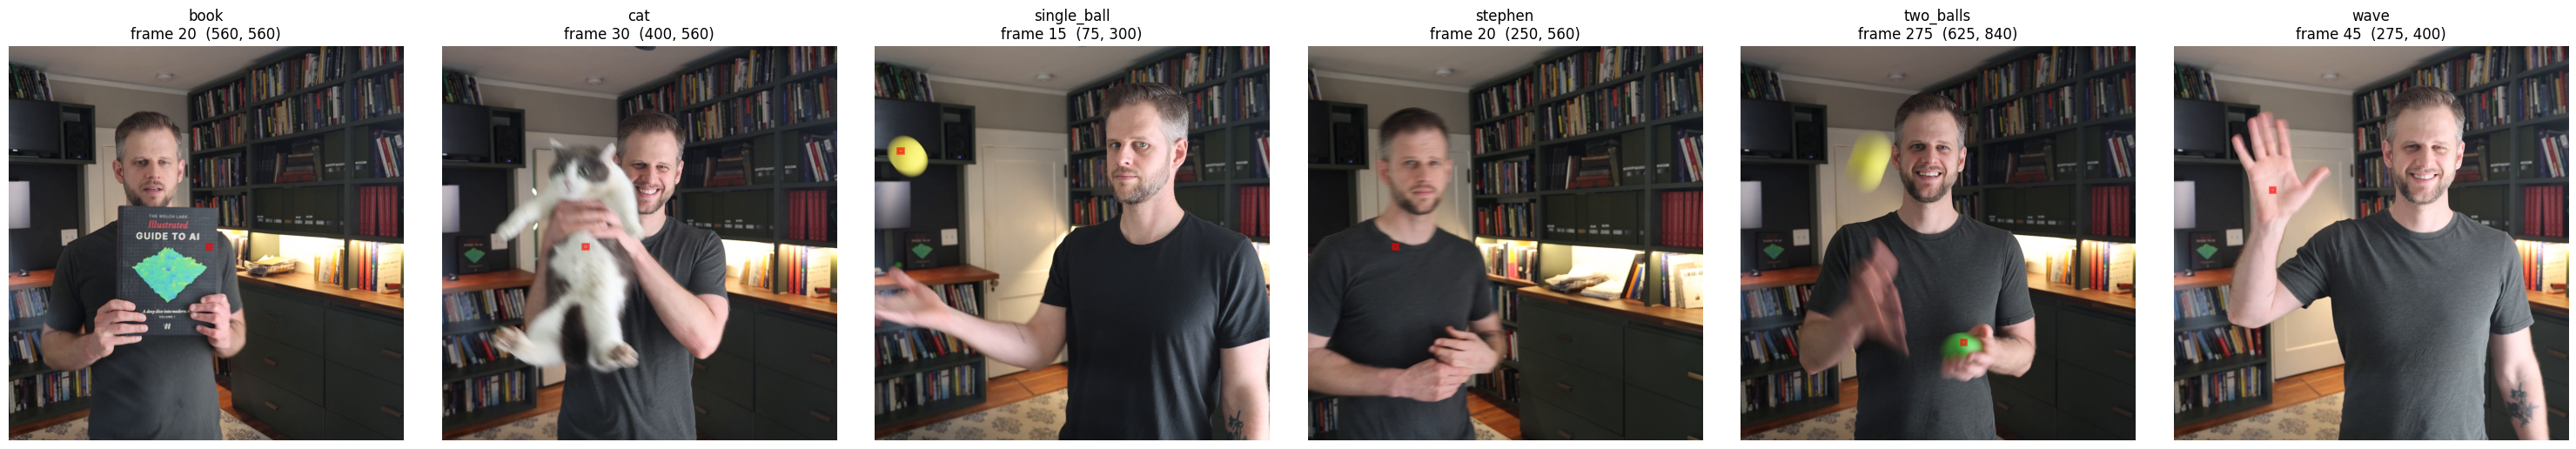

In [7]:
n = len(VIDEOS)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
if n == 1:
    axes = [axes]

for ax, v in zip(axes, VIDEOS):
    qr = v['query_y'] // PATCH_SIZE
    qc = v['query_x'] // PATCH_SIZE
    v['q_idx'] = qr * N_PATCHES + qc

    frame_idx = min(v['query_frame_idx'], len(v['frame_paths']) - 1)
    img = Image.open(v['frame_paths'][frame_idx])
    ax.imshow(img)
    ax.add_patch(plt.Rectangle(
        (qc * PATCH_SIZE, qr * PATCH_SIZE), PATCH_SIZE, PATCH_SIZE,
        linewidth=2, edgecolor='red', facecolor='red', alpha=0.5
    ))
    ax.set_title(f"{v['name']}\nframe {frame_idx}  ({v['query_x']}, {v['query_y']})")
    ax.axis('off')
    print(f"{v['name']}: patch ({qr},{qc})  flat idx {v['q_idx']}")

plt.tight_layout()
plt.savefig(f'{RUN_DIR}/query_locations.png', dpi=100, bbox_inches='tight')
plt.show()

## 4. Feature Similarity + PCA (all videos)

In [8]:
for v in VIDEOS:
    name        = v['name']
    frame_paths = v['frame_paths']
    fps         = v['fps']
    q_idx       = v['q_idx']
    qr          = v['query_y'] // PATCH_SIZE
    qc          = v['query_x'] // PATCH_SIZE
    query_fi    = min(v['query_frame_idx'], len(frame_paths) - 1)
    output_dir  = v['output_dir']

    print(f'\n=== {name} ===')

    # --- similarity ---
    q_feats = get_features(frame_paths[query_fi])
    q_vec   = F.normalize(q_feats[q_idx].unsqueeze(0), dim=-1)

    sim_dir = f'{output_dir}/similarity'
    os.makedirs(sim_dir, exist_ok=True)

    for fi, fpath in enumerate(tqdm(frame_paths, desc=f'{name} similarity')):
        feats   = F.normalize(get_features(fpath), dim=-1)
        sim     = (feats @ q_vec.T).squeeze(-1).cpu().numpy()
        sim_img = np.kron(sim.reshape(N_PATCHES, N_PATCHES), np.ones((PATCH_SIZE, PATCH_SIZE)))
        frame_np = np.array(Image.open(fpath))
        heat     = (cm.inferno(sim_img)[:, :, :3] * 255).astype(np.uint8)
        frame_marked = frame_np.copy()
        if fi == query_fi:
            cv2.rectangle(frame_marked,
                          (qc * PATCH_SIZE, qr * PATCH_SIZE),
                          ((qc + 1) * PATCH_SIZE, (qr + 1) * PATCH_SIZE),
                          (255, 0, 0), 2)
        side_by_side = np.concatenate([frame_marked, heat], axis=1)
        Image.fromarray(side_by_side).save(f'{sim_dir}/{fi:04d}.png')

    subprocess.run([
        'ffmpeg', '-y', '-framerate', str(fps),
        '-i', f'{sim_dir}/%04d.png',
        '-c:v', 'libx264', '-pix_fmt', 'yuv420p',
        f'{output_dir}/similarity.mp4'
    ], check=True, capture_output=True)
    subprocess.run([
        'ffmpeg', '-y', '-framerate', str(fps),
        '-i', f'{sim_dir}/%04d.png',
        '-vf', f'crop={IMG_SIZE}:{IMG_SIZE}:{IMG_SIZE}:0',
        '-c:v', 'libx264', '-pix_fmt', 'yuv420p',
        f'{output_dir}/similarity_only.mp4'
    ], check=True, capture_output=True)
    print(f'  similarity.mp4 done')

    # --- PCA ---
    sample_paths = frame_paths[::3][:60]
    all_feats = np.concatenate([
        get_features(fp).cpu().numpy()
        for fp in tqdm(sample_paths, desc=f'{name} PCA fit')
    ], axis=0)
    pca = PCA(n_components=3)
    pca.fit(all_feats)

    pca_dir = f'{output_dir}/pca'
    os.makedirs(pca_dir, exist_ok=True)

    for fi, fpath in enumerate(tqdm(frame_paths, desc=f'{name} PCA frames')):
        feats    = get_features(fpath).cpu().numpy()
        proj     = pca.transform(feats)
        proj     = (proj - proj.min(0)) / (proj.max(0) - proj.min(0) + 1e-8)
        pca_map  = np.kron(proj.reshape(N_PATCHES, N_PATCHES, 3), np.ones((PATCH_SIZE, PATCH_SIZE, 1)))
        pca_img  = (pca_map * 255).astype(np.uint8)
        frame_np = np.array(Image.open(fpath))
        Image.fromarray(np.concatenate([frame_np, pca_img], axis=1)).save(f'{pca_dir}/{fi:04d}.png')

    subprocess.run([
        'ffmpeg', '-y', '-framerate', str(fps),
        '-i', f'{pca_dir}/%04d.png',
        '-c:v', 'libx264', '-pix_fmt', 'yuv420p',
        f'{output_dir}/pca.mp4'
    ], check=True, capture_output=True)
    subprocess.run([
        'ffmpeg', '-y', '-framerate', str(fps),
        '-i', f'{pca_dir}/%04d.png',
        '-vf', f'crop={IMG_SIZE}:{IMG_SIZE}:{IMG_SIZE}:0',
        '-c:v', 'libx264', '-pix_fmt', 'yuv420p',
        f'{output_dir}/pca_only.mp4'
    ], check=True, capture_output=True)
    print(f'  pca.mp4 done')
    v['sim_dir'] = sim_dir
    v['pca_dir'] = pca_dir

print('\nAll videos done.')


=== book ===


book similarity: 100%|██████████| 411/411 [03:26<00:00,  1.99it/s]


  similarity.mp4 done


book PCA frames: 100%|██████████| 411/411 [03:52<00:00,  1.77it/s]


  pca.mp4 done

=== cat ===


...

  pca.mp4 done

=== wave ===


wave similarity: 100%|██████████| 106/106 [00:51<00:00,  2.07it/s]


  similarity.mp4 done


wave PCA frames: 100%|██████████| 106/106 [00:55<00:00,  1.92it/s]


  pca.mp4 done

All videos done.


## 5. Preview

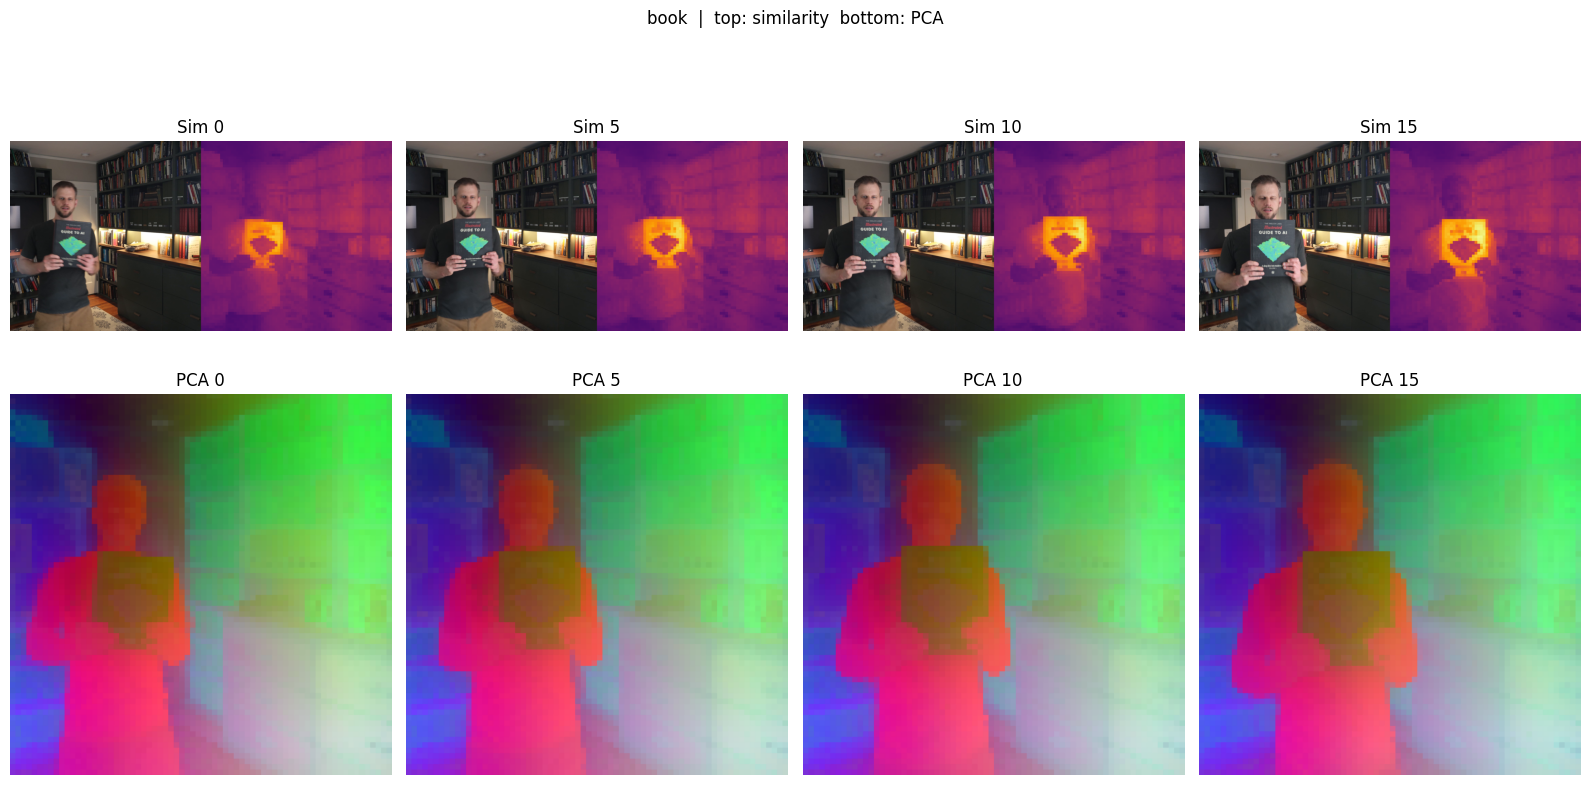

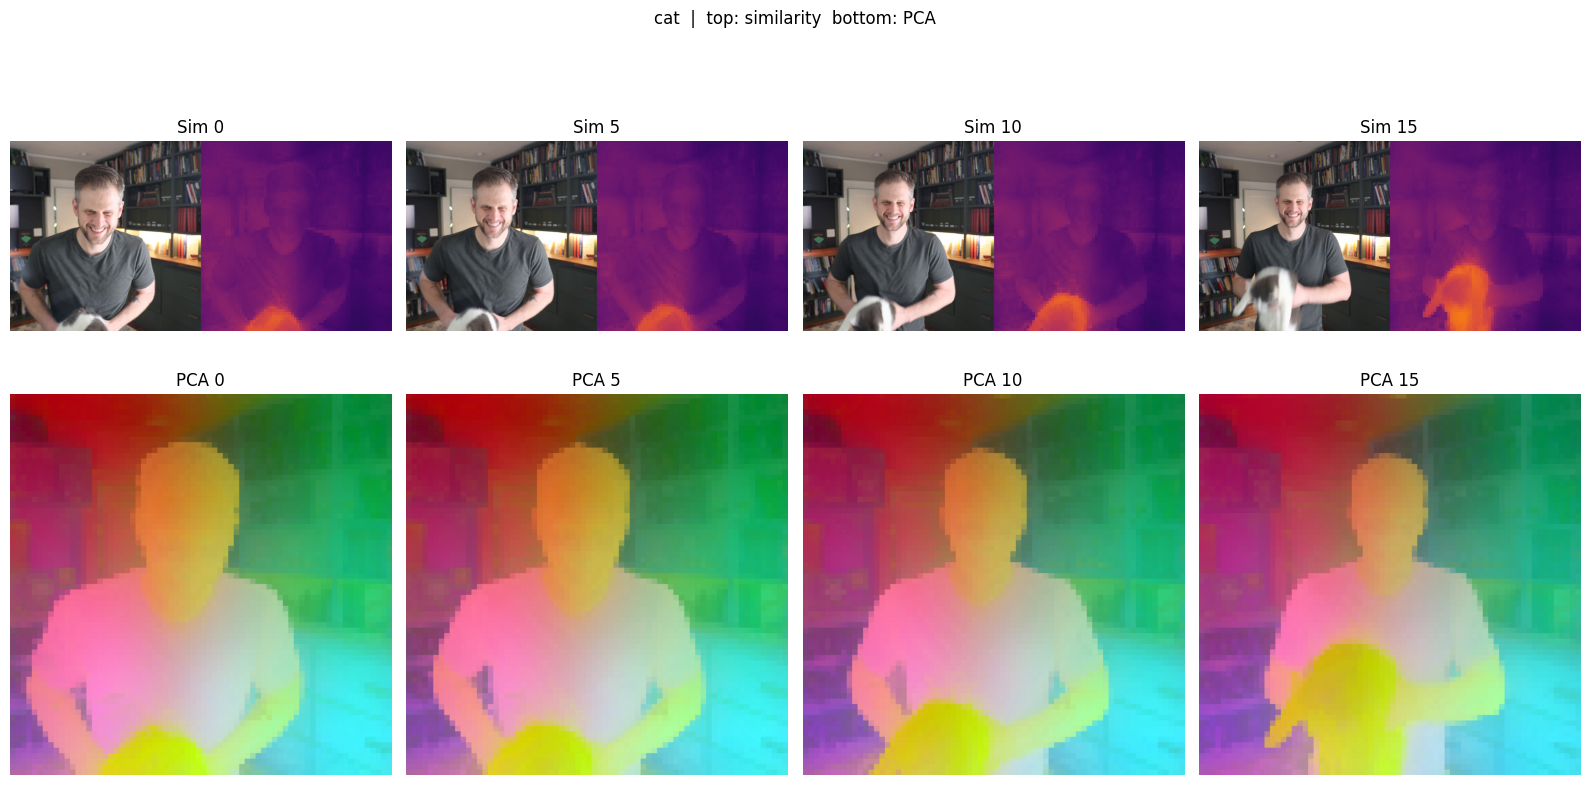

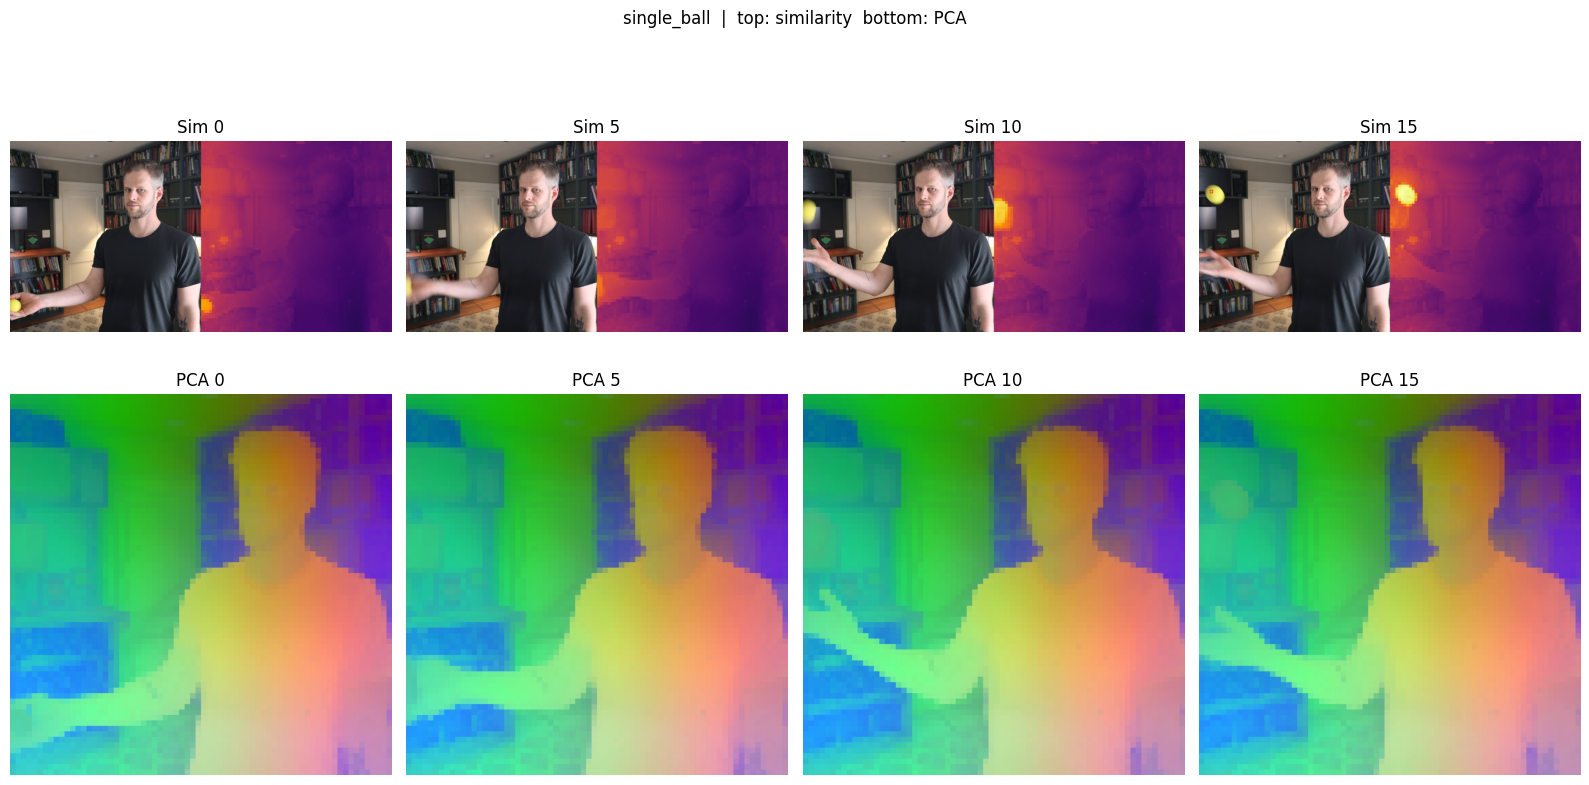

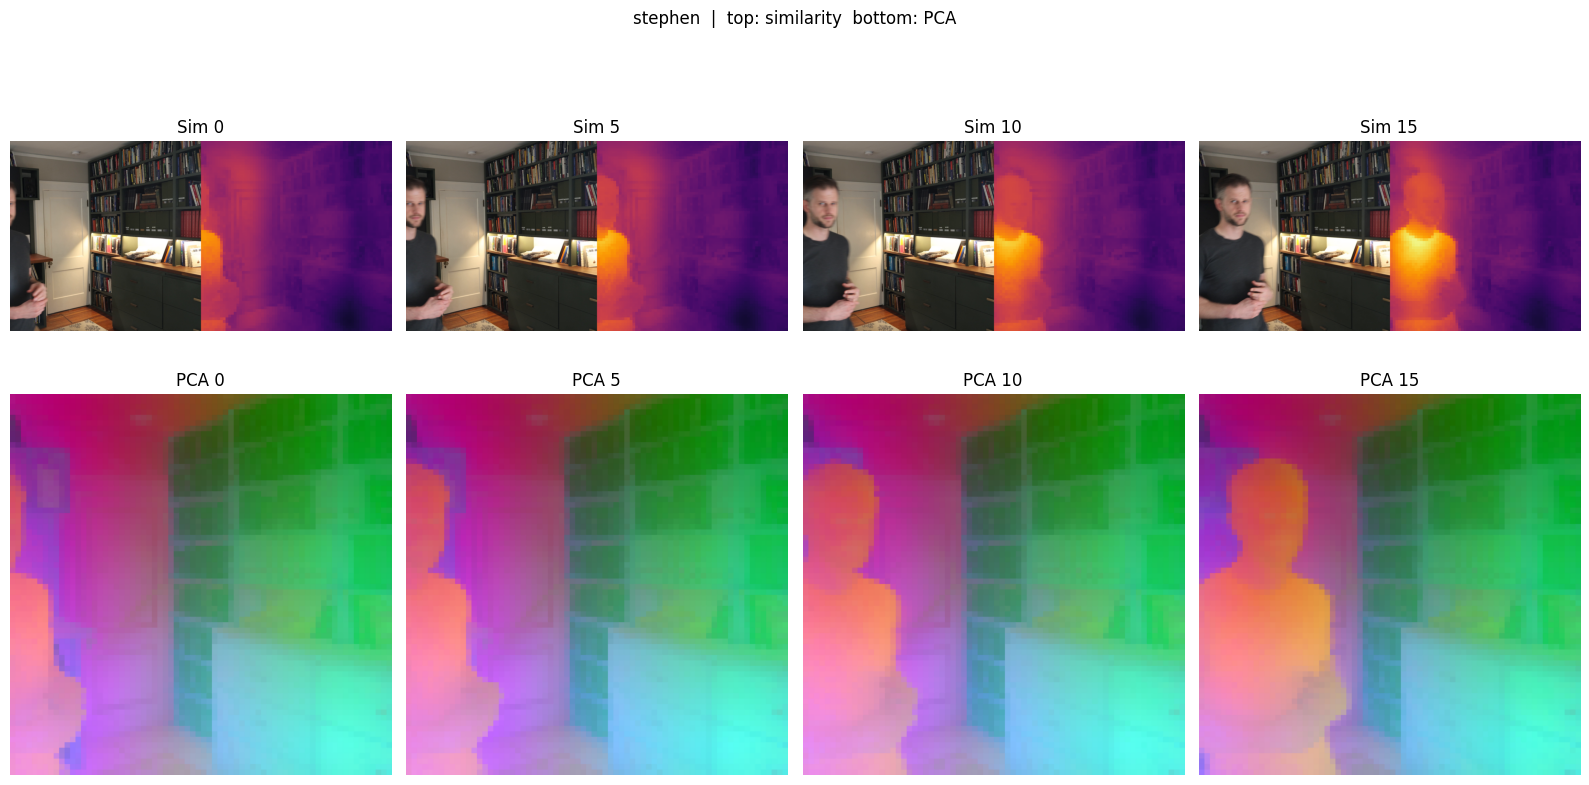

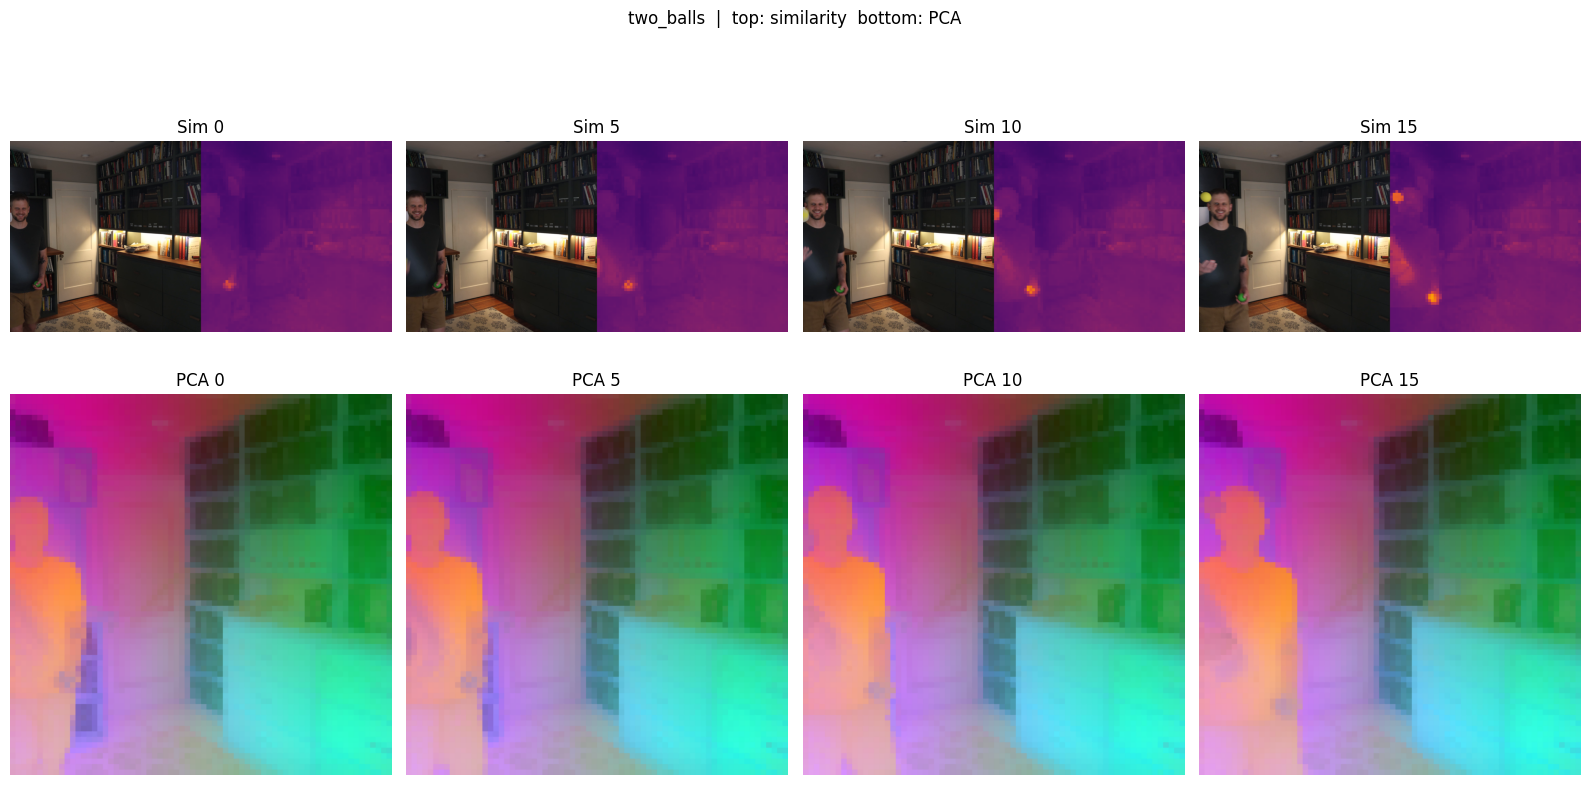

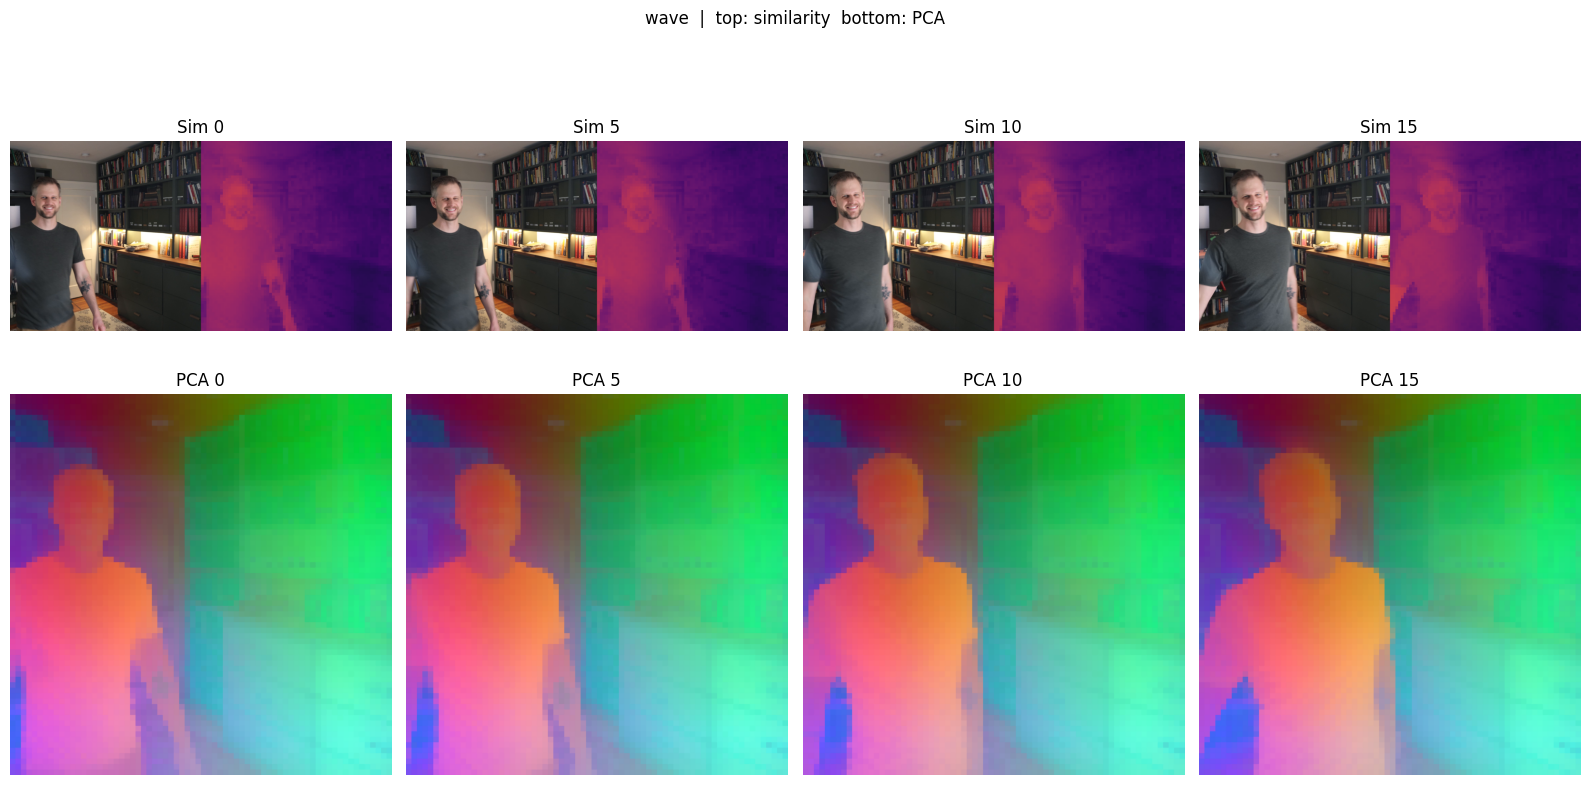

In [9]:
idxs = [0, 5, 10, 15]

for v in VIDEOS:
    name    = v['name']
    sim_dir = v['sim_dir']
    pca_dir = v['pca_dir']
    n_frames = len(v['frame_paths'])
    sample_idxs = [i for i in idxs if i < n_frames]

    fig, axes = plt.subplots(2, len(sample_idxs), figsize=(4 * len(sample_idxs), 8))
    if len(sample_idxs) == 1:
        axes = axes[:, None]

    for col, i in enumerate(sample_idxs):
        sim_f = Image.open(f'{sim_dir}/{i:04d}.png')
        pca_f = Image.open(f'{pca_dir}/{i:04d}.png')
        w = pca_f.width // 2
        axes[0, col].imshow(sim_f); axes[0, col].axis('off'); axes[0, col].set_title(f'Sim {i}')
        axes[1, col].imshow(pca_f.crop((w, 0, pca_f.width, pca_f.height)))
        axes[1, col].axis('off'); axes[1, col].set_title(f'PCA {i}')

    plt.suptitle(f'{name}  |  top: similarity  bottom: PCA')
    plt.tight_layout()
    plt.savefig(f"{v['output_dir']}/preview.png", dpi=100)
    plt.show()